# Foundations & Data Augmentation
## By: Parin Pengpun
## Super AI Engineer -- Computer Vision Lecture (Level 1)

This notebook covers the **building blocks** you need before training any model:
1. How images become tensors (numbers)
2. What convolution filters actually detect
3. Data augmentation -- your biggest free lever for hackathon performance
4. Loading data with ImageFolder + DataLoade

---
## Cell Group 1: Setup (1 min)

In [1]:
!pip install -q torchvision matplotlib Pillow scikit-learn

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import io
import requests
import urllib

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
GPU available: False


Downloaded image: 600x300 pixels


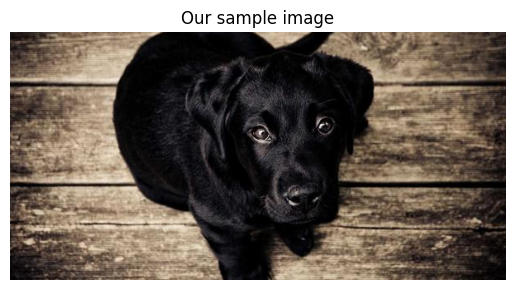

In [3]:
# Download a sample image (public domain from Unsplash)
url = "https://picsum.photos/id/237/600/300"
filepath = "local_image.png"
urllib.request.urlretrieve(url, filepath)

sample_image = Image.open(filepath).convert("RGB")
print(f"Downloaded image: {sample_image.size[0]}x{sample_image.size[1]} pixels")
plt.figure()
plt.imshow(sample_image)
plt.title("Our sample image")
plt.axis("off")
plt.show()

---
## Cell Group 2: Images as Tensors (5 min)

To a computer, an image is just a grid of numbers. Let's see that firsthand.

In [4]:
# Convert PIL image to a PyTorch tensor
to_tensor = transforms.ToTensor()
img_tensor = to_tensor(sample_image)

# What does the tensor look like?
print(f"Shape:  {img_tensor.shape}")        # (3, H, W) -- 3 channels, Height, Width
print(f"Dtype:  {img_tensor.dtype}")         # float32
print(f"Min:    {img_tensor.min().item():.4f}")   # 0.0 (black)
print(f"Max:    {img_tensor.max().item():.4f}")   # 1.0 (white)

# HACKATHON TIP: The shape is (Channels, Height, Width) -- NOT (H, W, C).
# PyTorch uses "channels first" format. This trips up beginners constantly!

Shape:  torch.Size([3, 300, 600])
Dtype:  torch.float32
Min:    0.0000
Max:    1.0000


In [7]:
img_tensor

tensor([[[0.1451, 0.1490, 0.1569,  ..., 0.1843, 0.1725, 0.1765],
         [0.1529, 0.1529, 0.1608,  ..., 0.1765, 0.1686, 0.1725],
         [0.0980, 0.0980, 0.0941,  ..., 0.2275, 0.2235, 0.2196],
         ...,
         [0.0157, 0.0235, 0.0275,  ..., 0.0275, 0.0314, 0.0314],
         [0.0196, 0.0235, 0.0275,  ..., 0.0196, 0.0196, 0.0196],
         [0.0235, 0.0353, 0.0392,  ..., 0.0118, 0.0157, 0.0157]],

        [[0.1255, 0.1294, 0.1373,  ..., 0.1451, 0.1333, 0.1373],
         [0.1333, 0.1333, 0.1412,  ..., 0.1373, 0.1294, 0.1333],
         [0.0824, 0.0824, 0.0784,  ..., 0.1882, 0.1843, 0.1804],
         ...,
         [0.0078, 0.0157, 0.0196,  ..., 0.0196, 0.0235, 0.0235],
         [0.0118, 0.0157, 0.0196,  ..., 0.0118, 0.0118, 0.0118],
         [0.0157, 0.0275, 0.0314,  ..., 0.0039, 0.0078, 0.0078]],

        [[0.1137, 0.1176, 0.1255,  ..., 0.1412, 0.1294, 0.1333],
         [0.1216, 0.1216, 0.1294,  ..., 0.1333, 0.1255, 0.1294],
         [0.0706, 0.0706, 0.0667,  ..., 0.1843, 0.1804, 0.

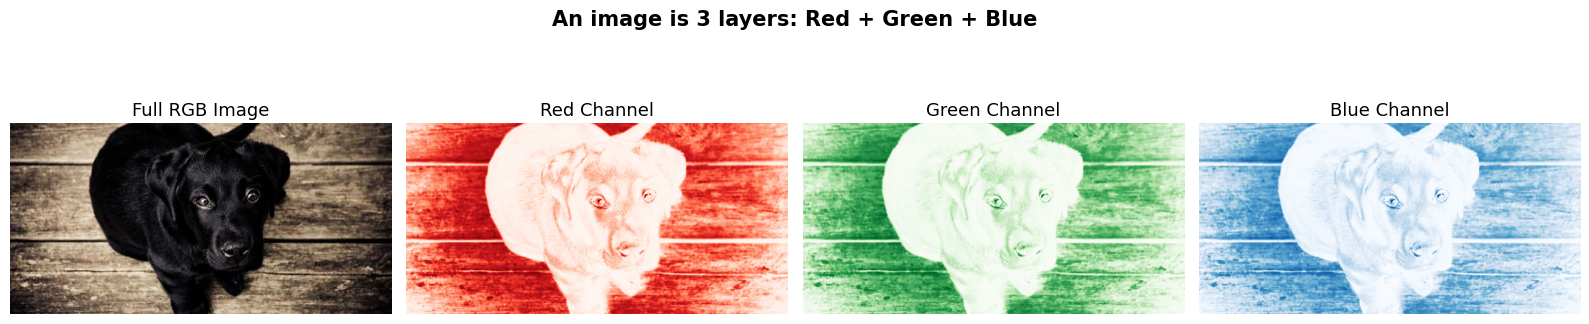

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Full color image -- need to rearrange from (C,H,W) to (H,W,C) for matplotlib
axes[0].imshow(img_tensor.permute(1, 2, 0))
axes[0].set_title("Full RGB Image", fontsize=13)
axes[0].axis("off")

# Individual channels as grayscale
channel_names = ["Red Channel", "Green Channel", "Blue Channel"]
cmaps = ["Reds", "Greens", "Blues"]
for i in range(3):
    axes[i+1].imshow(img_tensor[i], cmap=cmaps[i])
    axes[i+1].set_title(channel_names[i], fontsize=13)
    axes[i+1].axis("off")

plt.suptitle("An image is 3 layers: Red + Green + Blue", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# HACKATHON TIP: If your images look weird (all blue or wrong colors),
# you probably have a channel order problem. PIL uses RGB, OpenCV uses BGR!

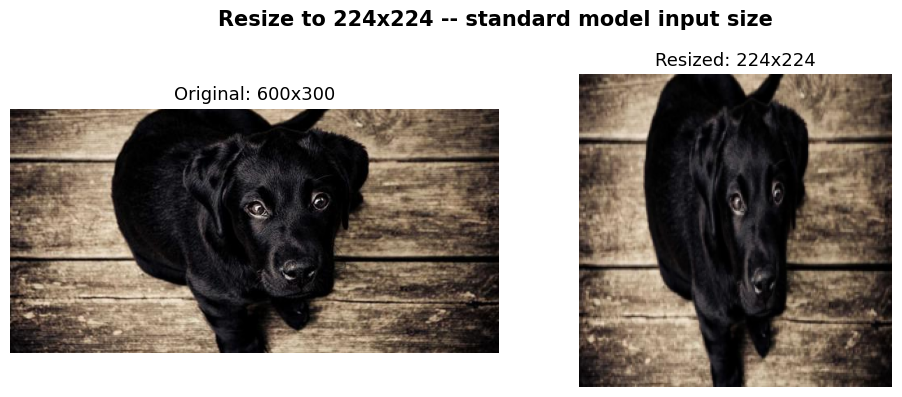

In [8]:
# Resize to 224x224 -- the standard input size for most models
resize_transform = transforms.Resize((224, 224))
img_resized = resize_transform(sample_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_image)
axes[0].set_title(f"Original: {sample_image.size[0]}x{sample_image.size[1]}", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_resized)
axes[1].set_title(f"Resized: 224x224", fontsize=13)
axes[1].axis("off")

plt.suptitle("Resize to 224x224 -- standard model input size", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# HACKATHON TIP: 224x224 is the default for ResNet, ViT, and most models.
# Some models use 384 or 512. Check the model card!

BEFORE normalization:
  Min: 0.0000, Max: 0.9490

AFTER normalization:
  Min: -2.1179, Max: 2.0263


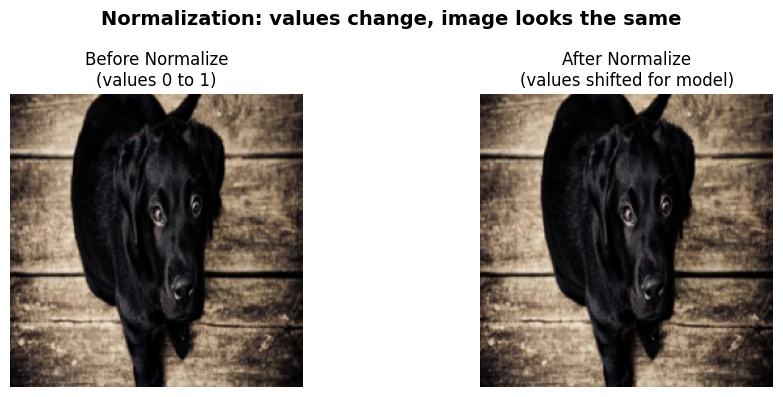

In [9]:
# Normalize with ImageNet statistics
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet means (R, G, B)
    std=[0.229, 0.224, 0.225]    # ImageNet stds (R, G, B)
)

img_tensor_224 = to_tensor(img_resized)
img_normalized = normalize(img_tensor_224)

print("BEFORE normalization:")
print(f"  Min: {img_tensor_224.min().item():.4f}, Max: {img_tensor_224.max().item():.4f}")
print(f"\nAFTER normalization:")
print(f"  Min: {img_normalized.min().item():.4f}, Max: {img_normalized.max().item():.4f}")

# Visually compare -- they look almost identical to us!
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_tensor_224.permute(1, 2, 0))
axes[0].set_title("Before Normalize\n(values 0 to 1)", fontsize=12)
axes[0].axis("off")

# To display normalized image, we need to undo normalization for visualization
img_display = img_normalized.clone()
for ch in range(3):
    img_display[ch] = img_display[ch] * torch.tensor([0.229, 0.224, 0.225])[ch] + torch.tensor([0.485, 0.456, 0.406])[ch]
axes[1].imshow(img_display.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("After Normalize\n(values shifted for model)", fontsize=12)
axes[1].axis("off")

plt.suptitle("Normalization: values change, image looks the same", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# HACKATHON TIP: ALWAYS use these exact ImageNet values when using pretrained models:
# mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

---
## Cell Group 3: What Do Convolution Filters See? (5 min)

A pretrained model has already learned what to look for. Let's peek inside and see the filters it learned.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 240MB/s]


conv1 filter shape: torch.Size([64, 3, 7, 7])
  = 64 filters, each 3 channels (RGB), each 7x7 pixels


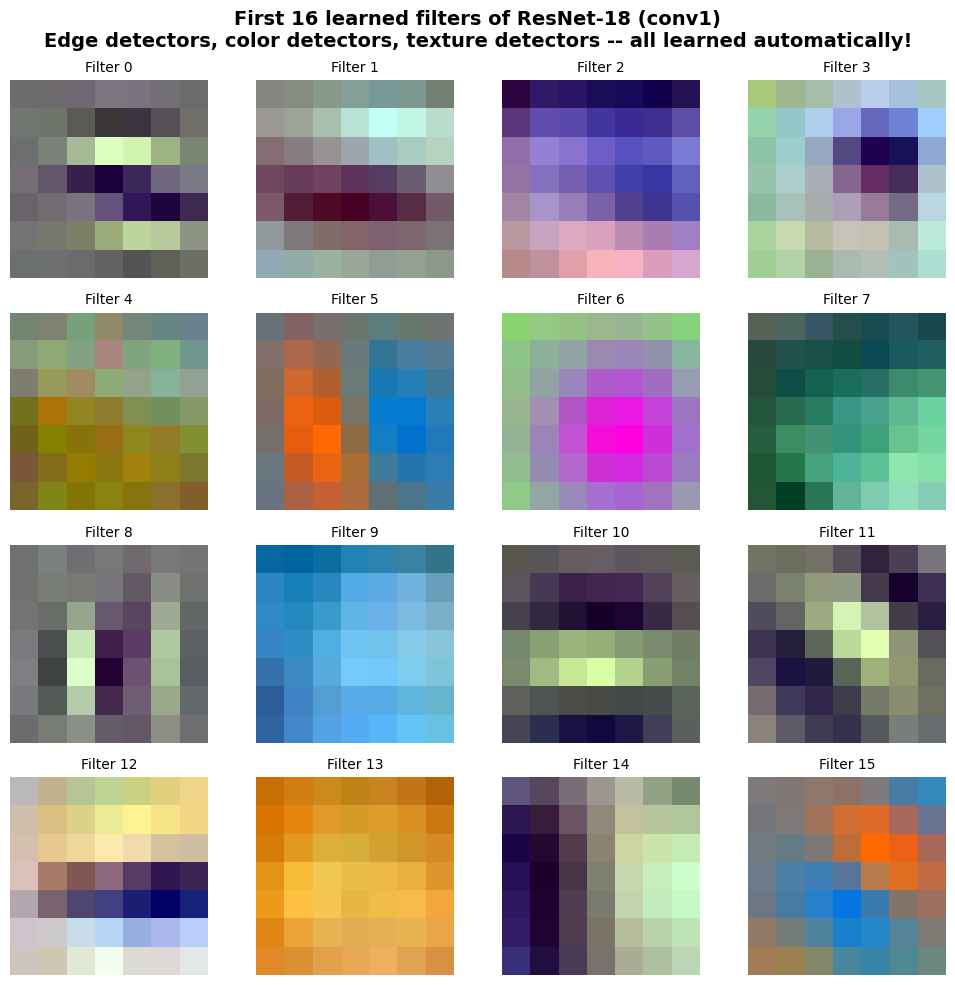

In [10]:
# Load pretrained ResNet-18
model = models.resnet18(weights="IMAGENET1K_V1")
model.eval()

# Extract first convolutional layer weights
conv1_weights = model.conv1.weight.data.clone()  # shape: (64, 3, 7, 7)
print(f"conv1 filter shape: {conv1_weights.shape}")
print(f"  = 64 filters, each 3 channels (RGB), each 7x7 pixels")

# Visualize the first 16 filters as a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    # Get filter i, normalize for display
    filt = conv1_weights[i]
    # Normalize each filter to 0-1 range for visualization
    filt = filt - filt.min()
    filt = filt / (filt.max() + 1e-8)
    # Show as RGB (permute from CxHxW to HxWxC)
    ax.imshow(filt.permute(1, 2, 0).numpy())
    ax.set_title(f"Filter {i}", fontsize=10)
    ax.axis("off")

plt.suptitle(
    "First 16 learned filters of ResNet-18 (conv1)\n"
    "Edge detectors, color detectors, texture detectors -- all learned automatically!",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

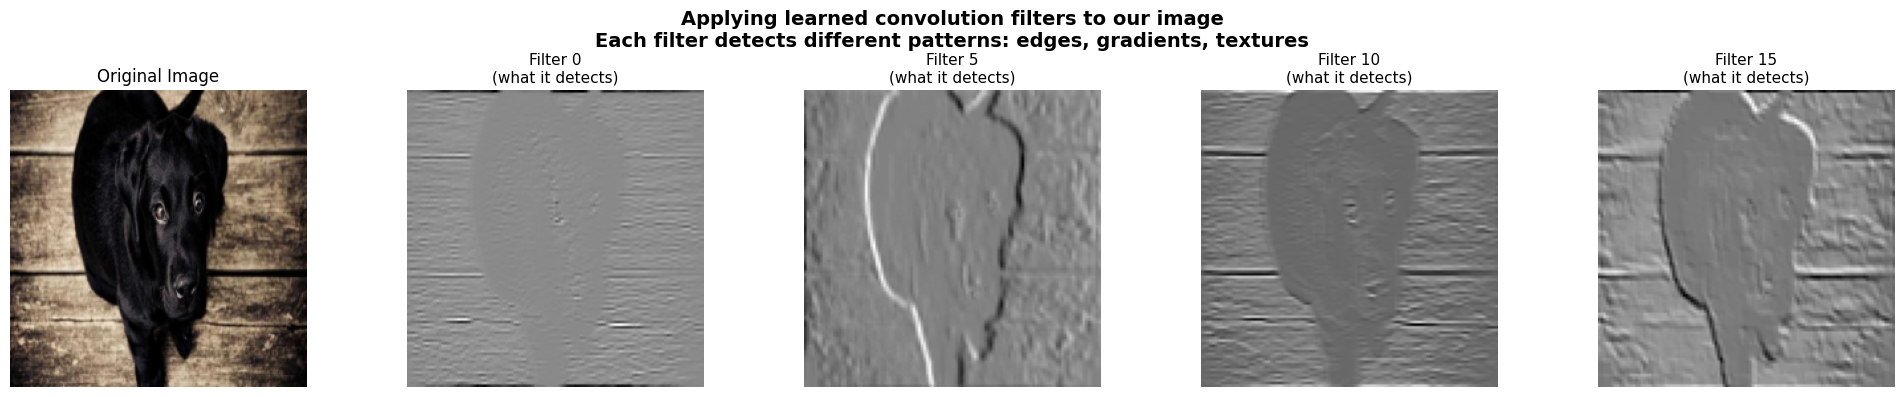

In [11]:
import torch.nn.functional as F

# Prepare the image: resize to 224x224 and convert to tensor
img_for_conv = to_tensor(img_resized).unsqueeze(0)  # shape: (1, 3, 224, 224)

# Pick 4 interesting filters to apply
filter_indices = [0, 5, 10, 15]  # Try different ones!
filter_labels = ["Filter 0", "Filter 5", "Filter 10", "Filter 15"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Show original image
axes[0].imshow(img_tensor_224.permute(1, 2, 0))
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

# Apply each filter using conv2d
for idx, (filt_i, label) in enumerate(zip(filter_indices, filter_labels)):
    # Get one filter: shape (1, 3, 7, 7) -- one output channel
    single_filter = conv1_weights[filt_i:filt_i+1]

    # Apply convolution manually
    with torch.no_grad():
        output = F.conv2d(img_for_conv, single_filter, stride=2, padding=3)

    # Display the output feature map
    feature_map = output.squeeze().numpy()
    axes[idx+1].imshow(feature_map, cmap="gray")
    axes[idx+1].set_title(f"{label}\n(what it detects)", fontsize=11)
    axes[idx+1].axis("off")

plt.suptitle(
    "Applying learned convolution filters to our image\n"
    "Each filter detects different patterns: edges, gradients, textures",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# HACKATHON TIP: You NEVER need to write convolution code yourself.
# PyTorch handles all of this inside the model. But knowing what happens
# under the hood helps you debug and choose the right model.

---
## Cell Group 4: Data Augmentation -- The Biggest Lever (8 min)

**This is the MOST IMPORTANT section for your hackathon.**

Data augmentation takes ONE image and creates MANY variations of it. More training data = better model. And it is completely FREE -- no new data collection needed.

> "Adding augmentation improves accuracy by 2-5% in most competitions -- for free."

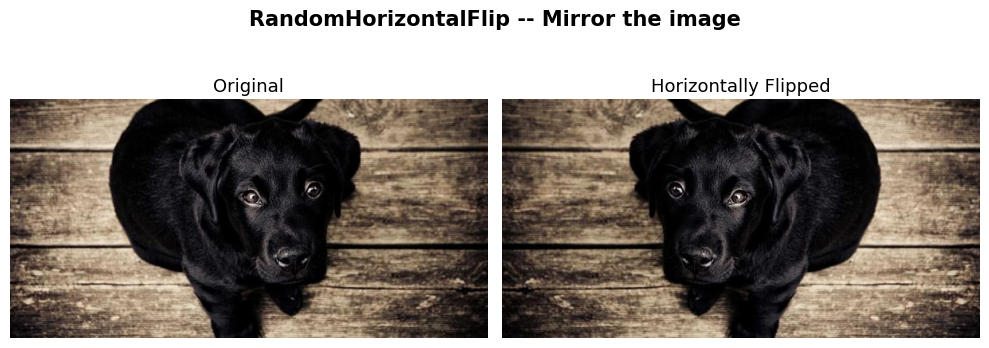

In [12]:
# ---- AUGMENTATION 1: RandomHorizontalFlip ----
flip = transforms.RandomHorizontalFlip(p=1.0)  # p=1.0 means ALWAYS flip (for demo)
img_flipped = flip(sample_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_image)
axes[0].set_title("Original", fontsize=13)
axes[0].axis("off")
axes[1].imshow(img_flipped)
axes[1].set_title("Horizontally Flipped", fontsize=13)
axes[1].axis("off")
plt.suptitle("RandomHorizontalFlip -- Mirror the image", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

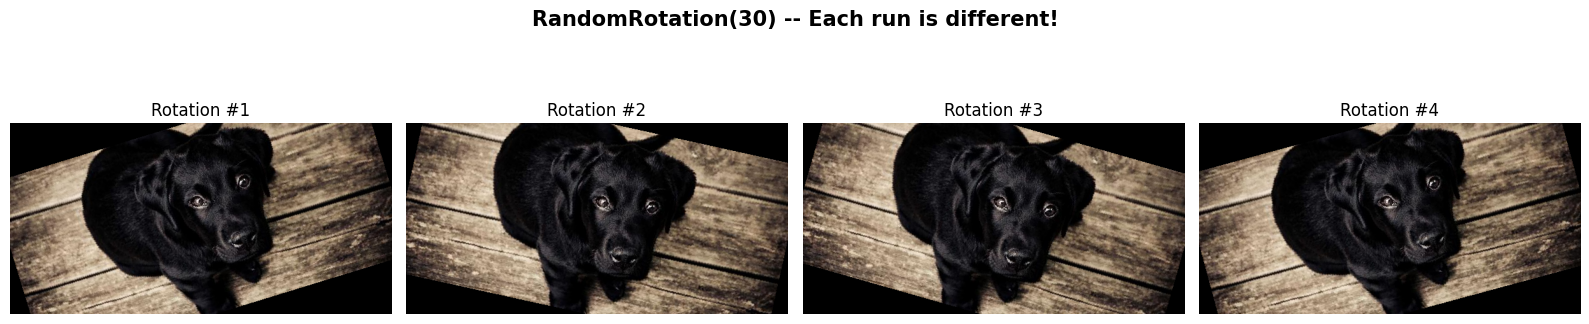

In [15]:
# ---- AUGMENTATION 2: RandomRotation ----
rotation = transforms.RandomRotation(degrees=30)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    rotated = rotation(sample_image)
    ax.imshow(rotated)
    ax.set_title(f"Rotation #{i+1}", fontsize=12)
    ax.axis("off")
plt.suptitle("RandomRotation(30) -- Each run is different!", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

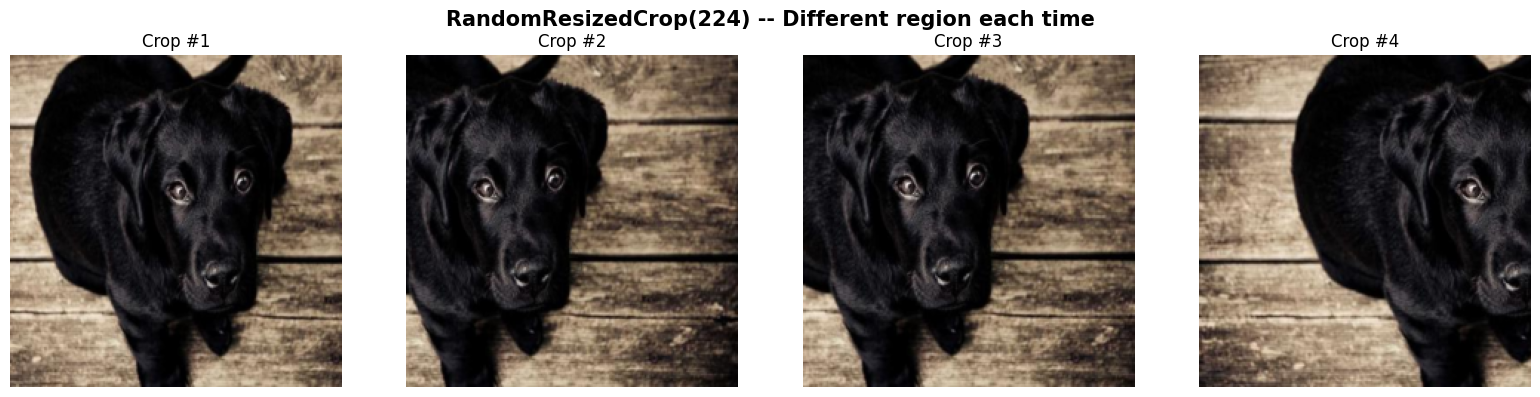

In [17]:
# ---- AUGMENTATION 3: RandomResizedCrop ----
random_crop = transforms.RandomResizedCrop(224, scale=(0.5, 1.0))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    cropped = random_crop(sample_image)
    ax.imshow(cropped)
    ax.set_title(f"Crop #{i+1}", fontsize=12)
    ax.axis("off")
plt.suptitle("RandomResizedCrop(224) -- Different region each time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

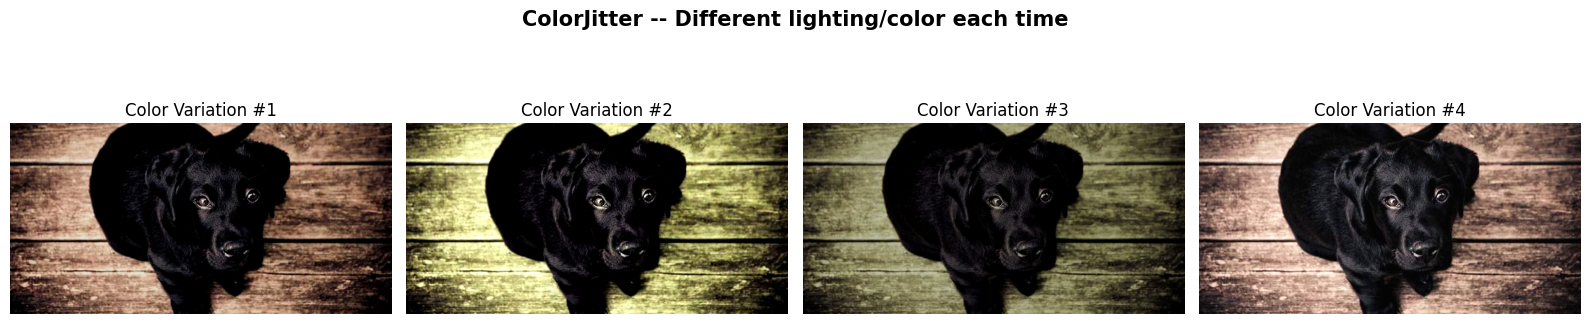

In [18]:
# ---- AUGMENTATION 4: ColorJitter ----
color_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    jittered = color_jitter(sample_image)
    ax.imshow(jittered)
    ax.set_title(f"Color Variation #{i+1}", fontsize=12)
    ax.axis("off")
plt.suptitle("ColorJitter -- Different lighting/color each time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

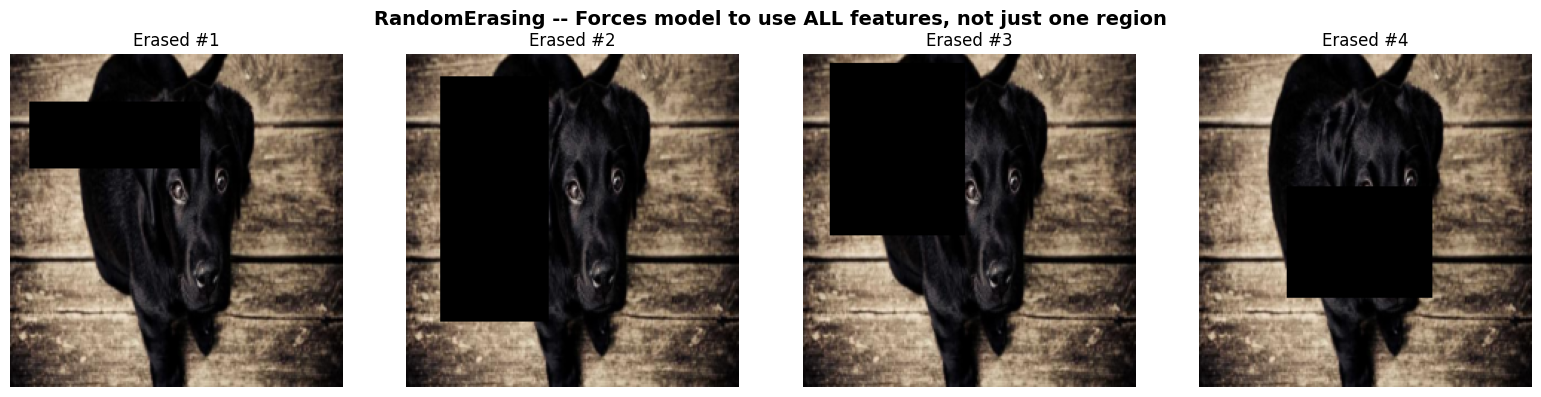

In [19]:
# ---- AUGMENTATION 5: RandomErasing ----
# RandomErasing works on tensors, so we convert first
erasing = transforms.RandomErasing(p=1.0, scale=(0.1, 0.25))
img_224_tensor = to_tensor(transforms.Resize((224, 224))(sample_image))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    erased = erasing(img_224_tensor.clone())
    ax.imshow(erased.permute(1, 2, 0))
    ax.set_title(f"Erased #{i+1}", fontsize=12)
    ax.axis("off")
plt.suptitle("RandomErasing -- Forces model to use ALL features, not just one region",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### The Complete Training Transform Pipeline

Now let's combine ALL of these into a single pipeline. This is the code you will copy into every hackathon notebook.

In [20]:
# ============================================================
# COPY THIS: Complete training transform for hackathons
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# ============================================================

print("train_transform defined!")
print("Augmentations: RandomResizedCrop -> RandomHorizontalFlip -> RandomRotation -> ColorJitter -> ToTensor -> Normalize")

train_transform defined!
Augmentations: RandomResizedCrop -> RandomHorizontalFlip -> RandomRotation -> ColorJitter -> ToTensor -> Normalize


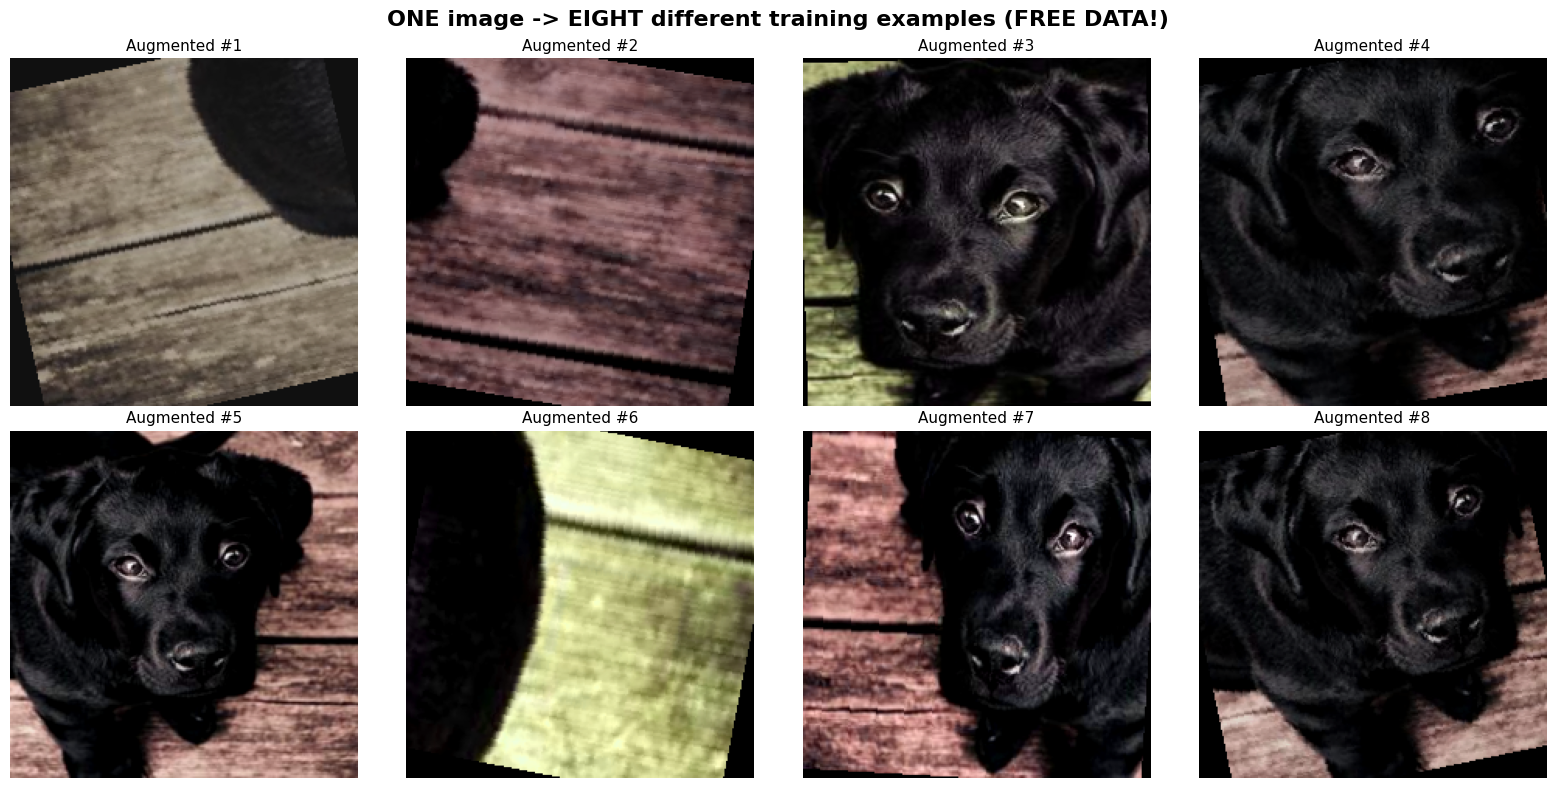

In [21]:
# Apply train_transform to the SAME image 8 times -- each result is different!
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    # Apply the full pipeline (result is a normalized tensor)
    augmented = train_transform(sample_image)

    # Undo normalization for display
    display_img = augmented.clone()
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    for ch in range(3):
        display_img[ch] = display_img[ch] * std[ch] + mean[ch]

    ax.imshow(display_img.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f"Augmented #{i+1}", fontsize=11)
    ax.axis("off")

plt.suptitle(
    "ONE image -> EIGHT different training examples (FREE DATA!)",
    fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.show()

# HACKATHON TIP: Run this cell multiple times -- you get different results every time!
# That is exactly what happens during training. Each epoch, the model sees different
# augmented versions of every image.

In [22]:
# ============================================================
# COPY THIS: Validation / test transform (NO augmentation!)
# ============================================================
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# ============================================================

print("val_transform defined!")
print("No augmentation: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize")
print()
print("RULE: Augment TRAINING data. NEVER augment validation/test data.")

val_transform defined!
No augmentation: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize

RULE: Augment TRAINING data. NEVER augment validation/test data.


### When NOT to Augment

Augmentation is powerful, but use common sense. Ask yourself: **"Would this augmentation create an IMPOSSIBLE example?"**

| Don't do this | Why |
|---|---|
| Flip medical images (X-rays, CT scans) | Left lung is NOT the right lung! |
| Rotate document/text images | Upside-down text is unreadable |
| Random crop on satellite images with coordinates | You'll lose spatial alignment |
| Vertical flip on street scenes | Cars don't drive upside down |
| Aggressive color jitter on color-critical tasks | Skin lesion color matters for diagnosis |

**The rule:** If a human would be confused by the augmented image, don't use that augmentation.

### Bonus: Mixup and CutMix (Advanced Techniques)

Two more powerful augmentation techniques used by top competitors:

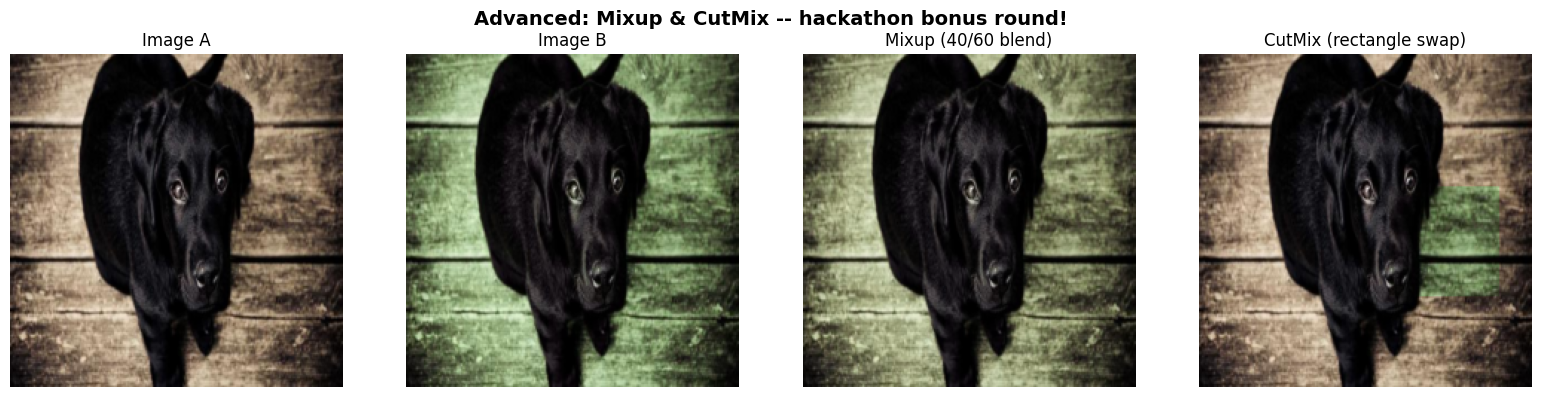

In [23]:
# Create a second image for the demo (just a color-shifted version)
img_a = to_tensor(transforms.Resize((224, 224))(sample_image))
img_b = to_tensor(transforms.Resize((224, 224))(transforms.ColorJitter(hue=0.3)(sample_image)))

# ----- MIXUP: Blend two images -----
alpha = 0.4  # Blend ratio
mixup_img = alpha * img_a + (1 - alpha) * img_b
# Label also becomes blended: e.g., 40% cat + 60% dog

# ----- CUTMIX: Paste a rectangle from image B onto image A -----
cutmix_img = img_a.clone()
# Paste a random rectangle
h, w = 224, 224
cut_h, cut_w = h // 3, w // 3
y1, x1 = np.random.randint(0, h - cut_h), np.random.randint(0, w - cut_w)
cutmix_img[:, y1:y1+cut_h, x1:x1+cut_w] = img_b[:, y1:y1+cut_h, x1:x1+cut_w]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_a.permute(1, 2, 0))
axes[0].set_title("Image A", fontsize=12)
axes[0].axis("off")
axes[1].imshow(img_b.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("Image B", fontsize=12)
axes[1].axis("off")
axes[2].imshow(mixup_img.permute(1, 2, 0).clamp(0, 1))
axes[2].set_title(f"Mixup (40/60 blend)", fontsize=12)
axes[2].axis("off")
axes[3].imshow(cutmix_img.permute(1, 2, 0).clamp(0, 1))
axes[3].set_title("CutMix (rectangle swap)", fontsize=12)
axes[3].axis("off")

plt.suptitle("Advanced: Mixup & CutMix -- hackathon bonus round!",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# HACKATHON TIP: timm and torchvision have built-in Mixup/CutMix support.
# Try adding them AFTER you have a baseline working. They can boost accuracy
# by 1-2% on larger datasets.

---
## Cell Group 5: DataLoader Boilerplate (7 min)

The `ImageFolder` + `DataLoader` pattern is how you feed images to any PyTorch model. You will use this in **every** hackathon notebook.

### The directory structure convention

```
data/
  train/
    cats/          <-- folder name = class name
      cat_001.jpg
      cat_002.jpg
    dogs/
      dog_001.jpg
      dog_002.jpg
  val/
    cats/
    dogs/
```

**PyTorch reads the folder names as class labels automatically.** No CSV, no JSON -- just organize your files into folders.

Dataset created!

train/
  circles/  (30 images)
  squares/  (30 images)
  triangles/  (30 images)

val/
  circles/  (10 images)
  squares/  (10 images)
  triangles/  (10 images)


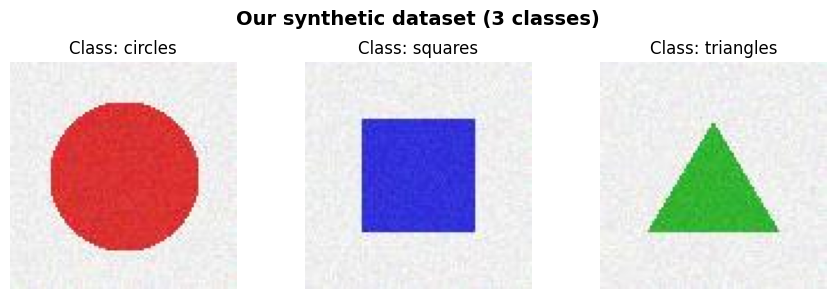

In [24]:
# Create a small synthetic dataset with colored shapes
# This simulates having real images organized in folders

def create_synthetic_image(shape_type, size=100):
    """Generate a simple synthetic image with a colored shape."""
    img = np.ones((size, size, 3), dtype=np.uint8) * 240  # light gray background

    if shape_type == "circle":
        # Red circle
        for y in range(size):
            for x in range(size):
                if (y - size//2)**2 + (x - size//2)**2 < (size//3)**2:
                    img[y, x] = [220, 50, 50]
    elif shape_type == "square":
        # Blue square
        margin = size // 4
        img[margin:size-margin, margin:size-margin] = [50, 50, 220]
    elif shape_type == "triangle":
        # Green triangle
        for y in range(size//4, size - size//4):
            half_w = int((y - size//4) * 0.6)
            cx = size // 2
            left = max(0, cx - half_w)
            right = min(size, cx + half_w)
            img[y, left:right] = [50, 180, 50]

    return Image.fromarray(img)

# Create the directory structure
base_dir = "/tmp/demo_dataset"
for split in ["train", "val"]:
    for cls in ["circles", "squares", "triangles"]:
        dir_path = os.path.join(base_dir, split, cls)
        os.makedirs(dir_path, exist_ok=True)

# Generate images -- 30 per class for train, 10 per class for val
shape_map = {"circles": "circle", "squares": "square", "triangles": "triangle"}
for split, num_imgs in [("train", 30), ("val", 10)]:
    for cls_name, shape_type in shape_map.items():
        for i in range(num_imgs):
            img = create_synthetic_image(shape_type)
            # Add small random noise to make each image slightly different
            img_arr = np.array(img)
            noise = np.random.randint(-15, 15, img_arr.shape, dtype=np.int16)
            img_noisy = Image.fromarray(np.clip(img_arr.astype(np.int16) + noise, 0, 255).astype(np.uint8))
            img_noisy = Image.fromarray(np.clip(np.array(img).astype(np.int16) + noise, 0, 255).astype(np.uint8))
            img_noisy.save(os.path.join(base_dir, split, cls_name, f"{shape_type}_{i:03d}.jpg"))

# Show what we created
print("Dataset created!")
for split in ["train", "val"]:
    print(f"\n{split}/")
    for cls in sorted(os.listdir(os.path.join(base_dir, split))):
        count = len(os.listdir(os.path.join(base_dir, split, cls)))
        print(f"  {cls}/  ({count} images)")

# Show sample images
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, (cls_name, shape_type) in enumerate(shape_map.items()):
    img = Image.open(os.path.join(base_dir, "train", cls_name, f"{shape_type}_000.jpg"))
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {cls_name}", fontsize=12)
    axes[i].axis("off")
plt.suptitle("Our synthetic dataset (3 classes)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# COPY THIS: ImageFolder + DataLoader pattern
# ============================================================
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# CHANGE THIS to your dataset path
TRAIN_DIR = "/tmp/demo_dataset/train"
VAL_DIR = "/tmp/demo_dataset/val"

# Load datasets with transforms
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(VAL_DIR, transform=val_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class-to-index mapping: {train_dataset.class_to_idx}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
# ============================================================

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# HACKATHON TIP: shuffle=True for training (randomize order each epoch).
# shuffle=False for validation (consistent evaluation).
# num_workers=2 is a safe default for Colab. Increase on better hardware.

Training samples: 90
Validation samples: 30
Classes: ['circles', 'squares', 'triangles']
Class-to-index mapping: {'circles': 0, 'squares': 1, 'triangles': 2}

Train batches: 3
Val batches: 1


Batch shape: torch.Size([32, 3, 224, 224])
Labels: [2, 0, 2, 2, 0, 1, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 2, 0, 1, 2, 0, 1, 2, 1, 1, 2]


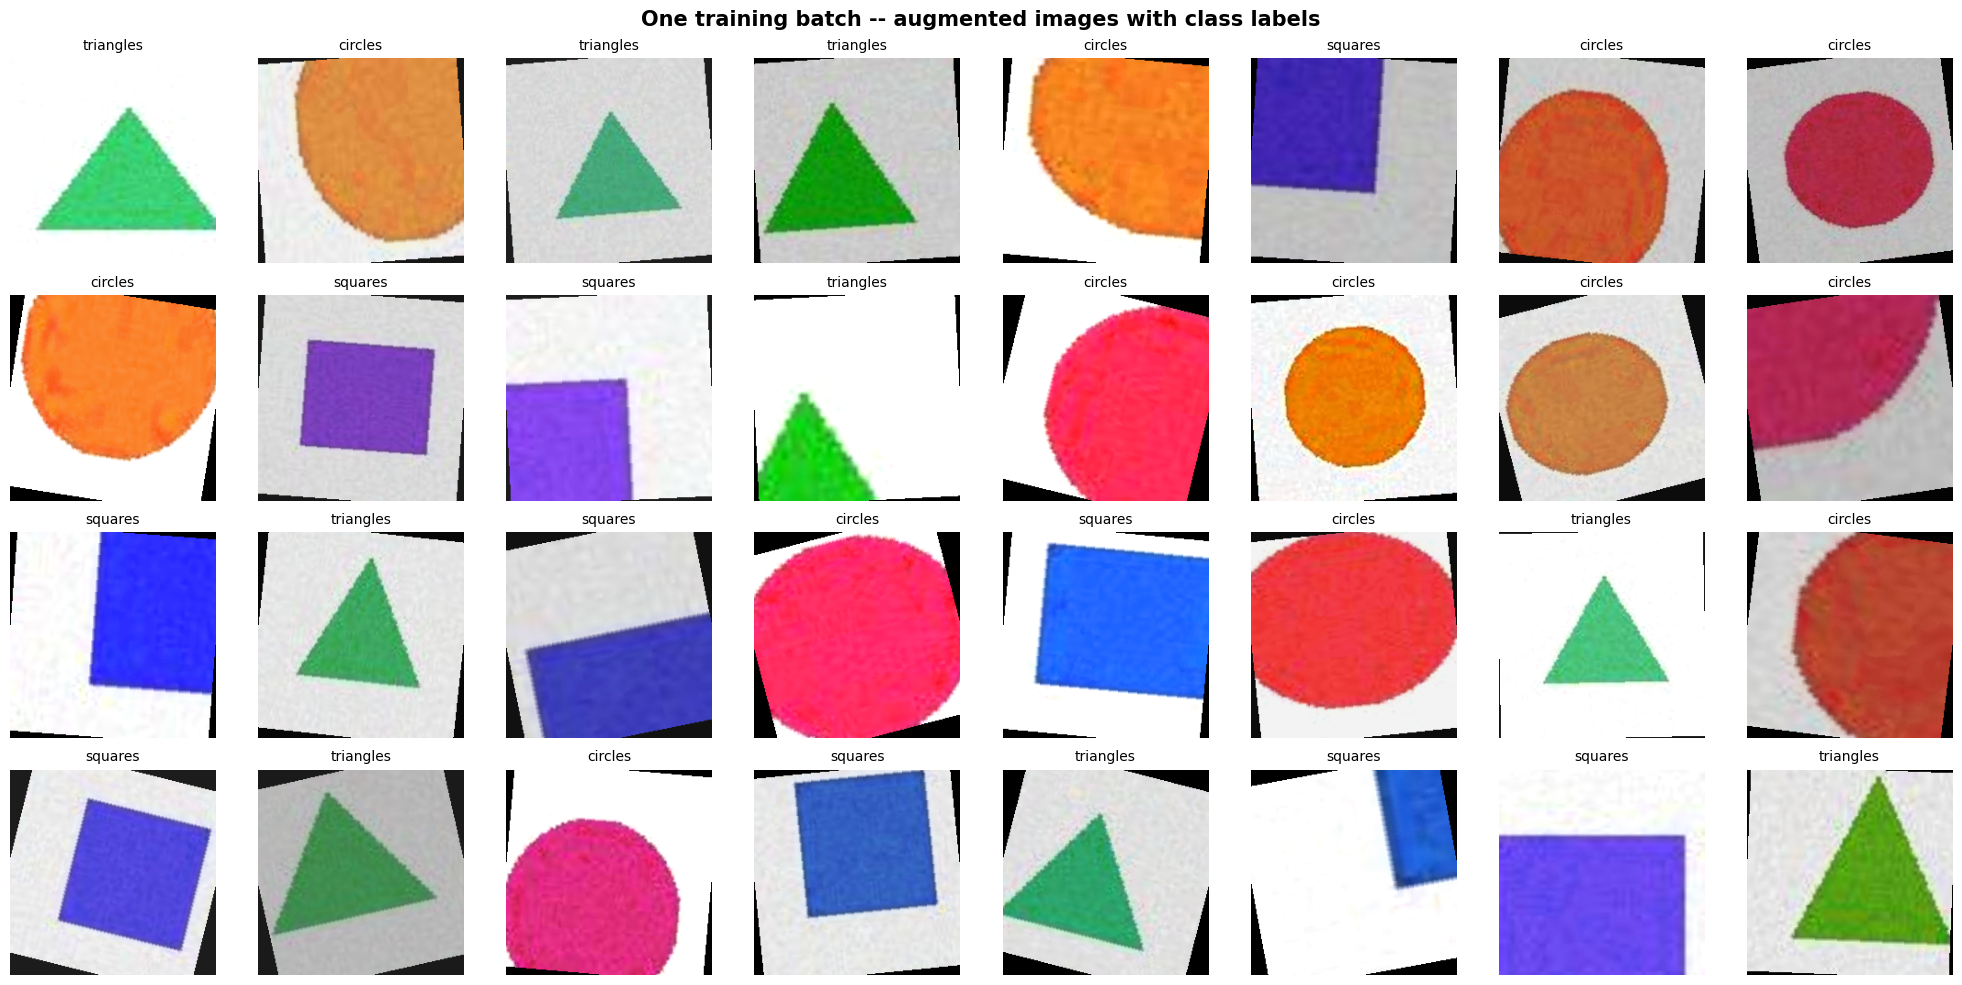

In [26]:
# Grab one batch from the training loader
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # (batch_size, 3, 224, 224)
print(f"Labels: {labels.tolist()}")

# Visualize the batch as a grid
class_names = train_dataset.classes
nrow = 8  # images per row
ncol = min(4, (len(images) + nrow - 1) // nrow)  # up to 4 rows

fig, axes = plt.subplots(ncol, nrow, figsize=(20, ncol * 2.5))
if ncol == 1:
    axes = axes.reshape(1, -1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(min(ncol * nrow, len(images))):
    row, col = i // nrow, i % nrow
    # Undo normalization for display
    img_display = images[i] * std + mean
    axes[row, col].imshow(img_display.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, col].set_title(class_names[labels[i]], fontsize=10)
    axes[row, col].axis("off")

# Hide any empty subplots
for i in range(len(images), ncol * nrow):
    row, col = i // nrow, i % nrow
    axes[row, col].axis("off")

plt.suptitle("One training batch -- augmented images with class labels",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# HACKATHON TIP: ALWAYS visualize your first batch! If images look wrong
# (all black, weird colors, upside down), fix your transforms before training.
# This one check can save you HOURS of debugging.

---
## You're Ready!

You now know:

- **How images become tensors** -- 3 channels (R, G, B), shape is (C, H, W), values 0-1
- **What convolutions detect** -- edges in early layers, textures in middle, objects at the end
- **How to augment your data (the biggest lever!)** -- flip, rotate, crop, color jitter = FREE data
- **How to load data into batches** -- ImageFolder + DataLoader is your go-to pattern

**Next: which MODEL should you use? That's coming up in the Architecture section.**

---

### Quick Reference: Copy-Paste Templates

```python
# TRAINING TRANSFORM (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# VALIDATION TRANSFORM (NO augmentation)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# DATA LOADING
train_dataset = ImageFolder('data/train', transform=train_transform)
val_dataset = ImageFolder('data/val', transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
```